# 02 - Preprocess and Window

Preprocessing pipeline to every trial listed in `metadata.csv`:

1. Load raw CSV
2. Skip first 2 seconds (rest→gesture transition)
3. Band-pass filter (20–95 Hz, Butterworth order 4)
4. Notch filter (50 Hz)
5. Sliding window segmentation (250 ms windows, stride 50 ms → images of shape (8, 50))
6. Save windows per-trial as `.npz` files under `data/processed/windows/`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from config import METADATA_PATH, WINDOW_SIZE, STRIDE_SIZE, SAMPLING_RATE
from src.preprocessing import process_all_trials, preprocess_trial, load_trial_windows

## Sanity check on a single trial first

In [2]:
metadata = pd.read_csv(METADATA_PATH)
print(f"Metadata rows: {len(metadata)}")

# Grab a single trial to inspect
sample_row = metadata.iloc[0]
print(f"\nInspecting: {sample_row['raw_file_path']}")

windows, labels = preprocess_trial(
    csv_path=sample_row["raw_file_path"],
    gesture_label=int(sample_row["gesture_label"]),
)

print(f"\nWindow array shape: {windows.shape}  (expected: (N, 8, 50))")
print(f"Label array shape: {labels.shape}")
print(f"All labels equal to gesture_label? {np.all(labels == sample_row['gesture_label'])}")
print(f"Value range after filtering: [{windows.min():.3f}, {windows.max():.3f}]")
print(f"Mean/std per channel (first 3): "
      f"{windows.mean(axis=(0, 2))[:3].round(3)} / {windows.std(axis=(0, 2))[:3].round(3)}")

Metadata rows: 24486

Inspecting: /Users/erdiantiwigaputriandini/Documents/Kuliah/Tugas Akhir/02. Dataset/SeNic (used)/h0/0-4/0/emg_p0_r0_eversion.csv

Window array shape: (118, 8, 50)  (expected: (N, 8, 50))
Label array shape: (118,)
All labels equal to gesture_label? True
Value range after filtering: [-138.735, 151.268]
Mean/std per channel (first 3): [ 0.003 -0.001 -0.001] / [30.501 10.582  6.312]


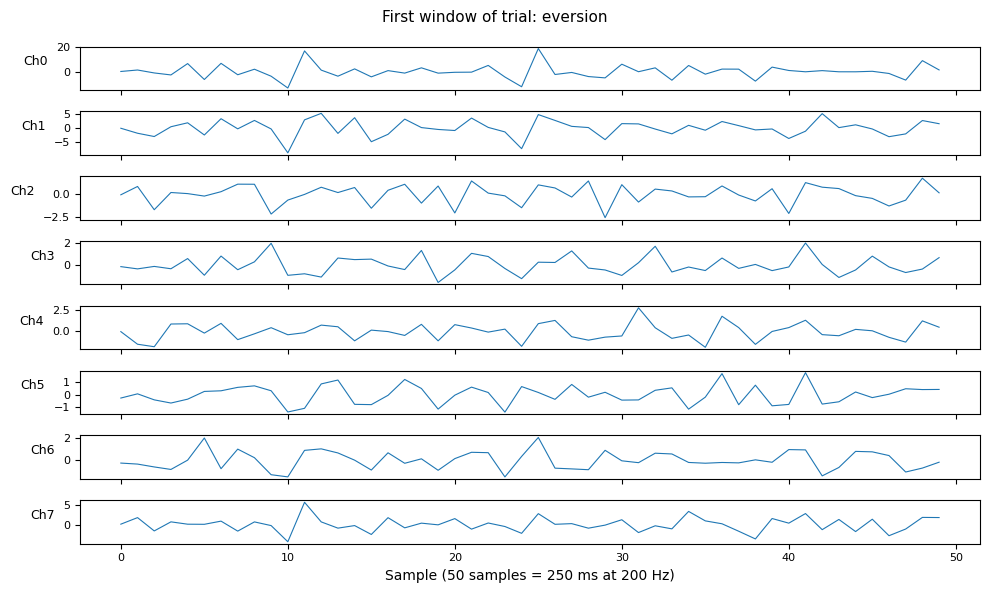

In [3]:
# Quick visualization: plot one window
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 1, figsize=(10, 6), sharex=True)
for ch in range(8):
    axes[ch].plot(windows[0, ch, :], linewidth=0.8)
    axes[ch].set_ylabel(f"Ch{ch}", rotation=0, labelpad=15, fontsize=9)
    axes[ch].tick_params(labelsize=8)
axes[-1].set_xlabel("Sample (50 samples = 250 ms at 200 Hz)")
fig.suptitle(f"First window of trial: {sample_row['gesture']}", fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
# Bandingkan sinyal raw vs filtered untuk 1 trial
from src.preprocessing import load_raw_trial, skip_rest_transition, filter_signal

raw = load_raw_trial(sample_row["raw_file_path"])
raw_skipped = skip_rest_transition(raw)
filtered = filter_signal(raw_skipped)

print(f"Raw range:      [{raw_skipped.min():.2f}, {raw_skipped.max():.2f}]")
print(f"Filtered range: [{filtered.min():.2f}, {filtered.max():.2f}]")
print(f"Raw std per channel:      {raw_skipped.std(axis=0).round(1)}")
print(f"Filtered std per channel: {filtered.std(axis=0).round(1)}")

Raw range:      [-128.00, 127.00]
Filtered range: [-138.73, 151.27]
Raw std per channel:      [33.1 11.4  6.8  7.6 13.  12.4 45.7 54. ]
Filtered std per channel: [30.  10.5  6.2  7.  12.2 11.3 40.9 48. ]


## Process all trials

In [5]:
updated_metadata = process_all_trials(overwrite=False, verbose=True)

  [500/24486] processed=500 skipped=0 empty=0
  [1000/24486] processed=1000 skipped=0 empty=0
  [1500/24486] processed=1500 skipped=0 empty=0
  [2000/24486] processed=2000 skipped=0 empty=0
  [2500/24486] processed=2500 skipped=0 empty=0
  [3000/24486] processed=3000 skipped=0 empty=0
  [3500/24486] processed=3500 skipped=0 empty=0
  [4000/24486] processed=4000 skipped=0 empty=0
  [4500/24486] processed=4500 skipped=0 empty=0
  [5000/24486] processed=5000 skipped=0 empty=0
  [5500/24486] processed=5500 skipped=0 empty=0
  [6000/24486] processed=6000 skipped=0 empty=0
  [6500/24486] processed=6500 skipped=0 empty=0
  [7000/24486] processed=7000 skipped=0 empty=0
  [7500/24486] processed=7500 skipped=0 empty=0
  [8000/24486] processed=8000 skipped=0 empty=0
  [8500/24486] processed=8500 skipped=0 empty=0
  [9000/24486] processed=9000 skipped=0 empty=0
  [9500/24486] processed=9500 skipped=0 empty=0
  [10000/24486] processed=10000 skipped=0 empty=0
  [10500/24486] processed=10500 skipped=

## Post-processing sanity checks

In [6]:
# Distribution of window counts per trial
print("Windows per trial - distribution:")
print(updated_metadata["n_windows"].describe())
print()
print("Any trials with 0 windows? (should be rare - only very short trials)")
zero_windows = updated_metadata[updated_metadata["n_windows"] == 0]
print(f"  Count: {len(zero_windows)}")
if len(zero_windows) > 0:
    print(zero_windows[["subject", "session", "position", "gesture"]].head())

Windows per trial - distribution:
count    24486.000000
mean       114.065139
std         18.192162
min          0.000000
25%        100.000000
50%        116.000000
75%        132.000000
max        138.000000
Name: n_windows, dtype: float64

Any trials with 0 windows? (should be rare - only very short trials)
  Count: 29
     subject  session  position             gesture
1906      h0        8         1           open_hand
1988      h0        8         5            eversion
2370      h1        0         1  pinch_middlefinger
2497      h1        0         7                 two
2614      h1        1         2    pinch_forefinger


In [7]:
# Verify we can round-trip: load a saved .npz and check shape
sample_row = updated_metadata.iloc[0]
w, l = load_trial_windows(sample_row["window_file_path"])
print(f"Loaded from disk - windows: {w.shape}, labels: {l.shape}")
print(f"dtype: windows={w.dtype}, labels={l.dtype}")

Loaded from disk - windows: (118, 8, 50), labels: (118,)
dtype: windows=float32, labels=int64


In [8]:
# Total data volume check
total_windows = int(updated_metadata["n_windows"].sum())
total_samples = total_windows * 8 * 50  # n_windows × channels × window_size
print(f"Total windows across dataset: {total_windows:,}")
print(f"Total float32 values: {total_samples:,}")
print(f"Approx uncompressed size: {total_samples * 4 / 1e9:.2f} GB (compressed on disk will be smaller)")

Total windows across dataset: 2,792,999
Total float32 values: 1,117,199,600
Approx uncompressed size: 4.47 GB (compressed on disk will be smaller)
